<a href="https://colab.research.google.com/github/Saikat98/Code-Experiments-on-Jupyter/blob/main/Neural_Network_Architecture_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
%matplotlib inline

In [ ]:
np.random.seed(42)
random.seed(42)

1) Creating a datastucture of backpropagation

In [ ]:
class Value:
  def __init__(self, data, _children=(), _op='',label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __radd__(self, other): # other + self
    return self + other

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other): # other + self
    return self * other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def relu(self): # activation function
    out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

    def _backward():
        self.grad += (out.data > 0) * out.grad
    out._backward = _backward

    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out

  def __sub__(self, other): # self - other
    return self + (-other)

 - Implementing with a simple expression

In [ ]:
w = Value(-3); w.label ="w"
x = Value(2); x.label ="x"
b = Value(6.88); b.label ="b"
wx = w * x; wx.label = "wx"
n = wx + b; n.label ="n"
o = n.tanh(); o.label ="o"

In [ ]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


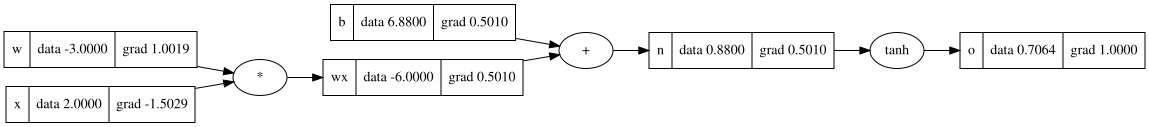

In [ ]:
draw_dot(o)

In [ ]:
# backpropagation to calculate gradient at each node
o.backward()

2) Building a datastructure of Neurons, Layers and implementing them in a Multi Layer Perceptron

In [ ]:
class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
      self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
      outs = [n(x) for n in self.neurons]
      return outs[0] if len(outs)==1 else outs

    def parameters(self):
      return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

  def __call__(self,x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

 - Implementing backpropagation and training a single neuron on a small training set

In [ ]:
nn = Neuron(1)

In [ ]:
# sample data
xs = [
    [1.5],
    [-0.01],
    [-2.8],
    [0.1]
]

ys = [1.0,0.0,-1.0,0.0] # desired targets

In [ ]:
nn.parameters()

[Value(data=-0.7865062238308345), Value(data=0.902276865696356)]

In [ ]:
for k in range(20):

  # forward pass
  ypred = [nn(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in nn.parameters():
    p.grad = 0.0
  loss.backward()

  # update
  for p in nn.parameters():
    p.data += -0.01 * p.grad

  print(k, loss.data)

0 0.08582797411195633
1 0.0839184624065554
2 0.0821061141751636
3 0.08038412536861743
4 0.07874622168019914
5 0.07718661759029716
6 0.07569997822389042
7 0.07428138389502523
8 0.07292629720632537
9 0.07163053256798892
10 0.07039022799932679
11 0.06920181907634684
12 0.06806201489084869
13 0.06696777588968883
14 0.06591629346702114
15 0.06490497118719638
16 0.06393140752140417
17 0.06299337998689898
18 0.062088830583614585
19 0.06121585242903051


In [ ]:
ypred

[Value(data=0.7925550146422151),
 Value(data=0.04385384945013424),
 Value(data=-0.9533514485064535),
 Value(data=0.11867258744502802)]

 - Training a 3(input) x 4(hidden) x 4(hidden) x 1(output) layer neural network

In [ ]:
nn = MLP(3, [4, 4, 1])

In [ ]:
# sample data
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [ ]:
for k in range(20):

  # forward pass
  ypred = [nn(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in nn.parameters():
    p.grad = 0.0
  loss.backward()

  # update
  for p in nn.parameters():
    p.data += -0.1 * p.grad

  print(k, loss.data)

0 4.624220217448574
1 3.75398785746419
2 4.089232531696889
3 4.461538844990401
4 0.09625321057249503
5 0.06426995860931385
6 0.04970923258797352
7 0.04088824780695837
8 0.03485054455106547
9 0.030416422176476714
10 0.027004707902591126
11 0.024290428190537734
12 0.022075623065857336
13 0.020231969701163706
14 0.018672248841142505
15 0.017334916579586454
16 0.016175204858583068
17 0.015159715915615275
18 0.014262997227998588
19 0.013465293403118795


In [ ]:
ypred

[Value(data=0.9431993865745062),
 Value(data=-0.942019975295245),
 Value(data=-0.9464521056082716),
 Value(data=0.9366760435612658)]

In [ ]:
draw_dot(loss)

 - Implementing more complex neural network

In [ ]:
# loss function
def loss(batch_size=None):
    # inline DataLoader :)
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
    inputs = [list(map(Value, xrow)) for xrow in Xb]

    # forward the model to get scores
    scores = list(map(model, inputs))

    # svm "max-margin" loss
    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    # L2 regularization
    alpha = 1e-4
    reg_loss = alpha * sum((p*p for p in model.parameters()))
    total_loss = data_loss + reg_loss

    # also get accuracy
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

In [ ]:
# function to visualize decision boundary
def plotBoundary(k,acc):
    ax.clear()  # Clear previous plot for each frame
    h = 0.25
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Xmesh = np.c_[xx.ravel(), yy.ravel()]
    inputs = [list(map(Value, xrow)) for xrow in Xmesh]
    scores = list(map(model, inputs))
    Z = np.array([s.data > 0 for s in scores])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(f"Step {k}, Accuracy {acc}")

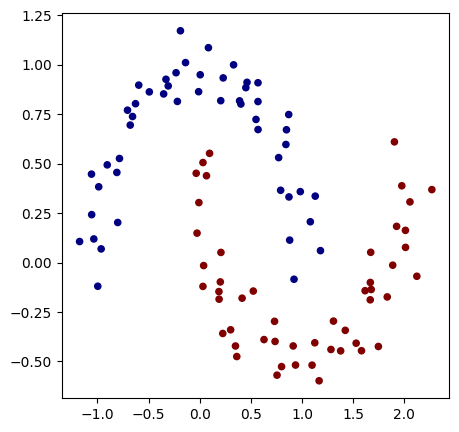

In [ ]:
# make up a dataset

from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')
plt.show()

In [ ]:
# initialize a model
model = MLP(2, [16, 16, 1]) # 2-layer neural network
print("number of parameters", len(model.parameters()))

number of parameters 337


step 0 loss 0.8664108933087415, accuracy 51.0%
step 0 loss 0.4675338635386195, accuracy 78.0%
step 1 loss 0.40290480362907133, accuracy 81.0%
step 2 loss 0.37029174152140387, accuracy 82.0%
step 3 loss 0.33198132540557224, accuracy 85.0%
step 4 loss 0.31018559368434206, accuracy 86.0%
step 5 loss 0.29260260039013264, accuracy 86.0%
step 6 loss 0.27098786849985346, accuracy 89.0%
step 7 loss 0.256704652481097, accuracy 89.0%
step 8 loss 0.2504392381072292, accuracy 89.0%
step 9 loss 0.24604121662301798, accuracy 89.0%
step 10 loss 0.24223833998937347, accuracy 89.0%
step 11 loss 0.23897409417137502, accuracy 89.0%
step 12 loss 0.23595626140727402, accuracy 89.0%
step 13 loss 0.23303931641354514, accuracy 90.0%
step 14 loss 0.23015253315904713, accuracy 90.0%
step 15 loss 0.2272414175106675, accuracy 90.0%
step 16 loss 0.22425666723832274, accuracy 90.0%
step 17 loss 0.22114957017291276, accuracy 90.0%
step 18 loss 0.21786826690478028, accuracy 90.0%
step 19 loss 0.21435343600169238, acc

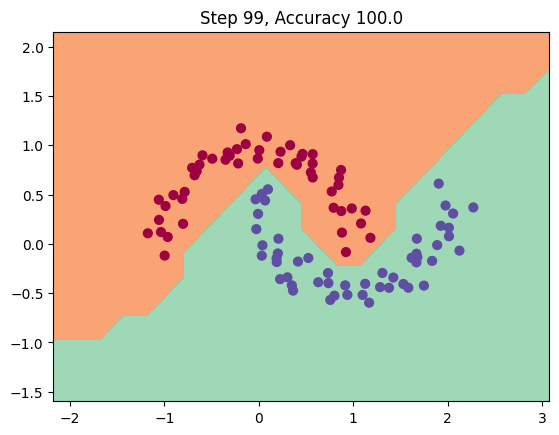

In [ ]:
# training
fig, ax = plt.subplots()

# Update function for the animation
def update(k):
    # forward pass
    total_loss, acc = loss()

    # backward pass
    for p in model.parameters():
        p.grad = 0.0
    total_loss.backward()

    # update (sgd)
    learning_rate = 1.0 - 0.9 * k / 100
    for p in model.parameters():
        p.data -= learning_rate * p.grad

    print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")

    # Plot the boundary for this step
    plotBoundary(k,acc*100)

# Create the animation
ani = FuncAnimation(fig, update, frames=100, repeat=False)

# Save the animation as a gif (optional)
ani.save("boundary_animation.gif", writer=PillowWriter(fps=10))

plt.show()

 - Another example

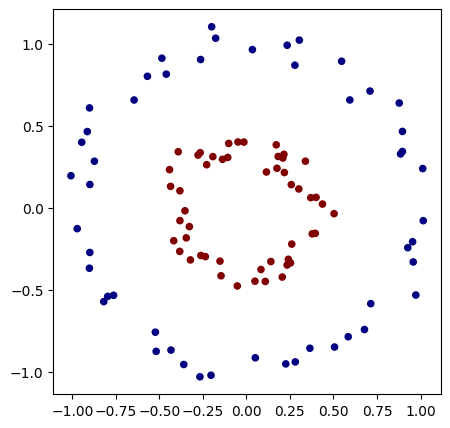

In [ ]:
# make up a dataset

from sklearn.datasets import make_circles
X, y = make_circles(n_samples=100, factor=0.4, noise=0.06)

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [ ]:
# initialize a model
model = MLP(2, [8, 16, 1]) # 2-layer neural network
print("number of parameters", len(model.parameters()))

number of parameters 185


step 0 loss 0.9888431229818125, accuracy 50.0%
step 0 loss 0.8679739142480101, accuracy 50.0%
step 1 loss 0.8632686279471737, accuracy 50.0%
step 2 loss 0.9695218416464252, accuracy 50.0%
step 3 loss 0.8487057613695279, accuracy 50.0%
step 4 loss 0.9528922470864725, accuracy 50.0%
step 5 loss 0.6697375920087079, accuracy 88.0%
step 6 loss 0.8462172853988236, accuracy 50.0%
step 7 loss 0.9316385034116732, accuracy 50.0%
step 8 loss 0.5385957374275014, accuracy 86.0%
step 9 loss 0.572140891797415, accuracy 84.0%
step 10 loss 1.0004871633531207, accuracy 50.0%
step 11 loss 0.9973187381939201, accuracy 50.0%
step 12 loss 0.9898695164888229, accuracy 50.0%
step 13 loss 0.9632930615810666, accuracy 50.0%
step 14 loss 0.7736170908596957, accuracy 61.0%
step 15 loss 0.7389387491165597, accuracy 62.0%
step 16 loss 0.7961580964275484, accuracy 61.0%
step 17 loss 0.6139023408382235, accuracy 68.0%
step 18 loss 0.3295910028111922, accuracy 96.0%
step 19 loss 0.28450702357097385, accuracy 99.0%
ste

KeyboardInterrupt: 

step 0 loss 0.8948098965659691, accuracy 50.0%


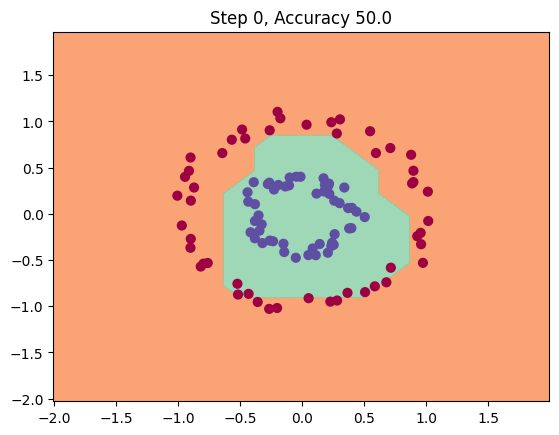

In [ ]:
# training
fig, ax = plt.subplots()

# Update function for the animation
def update(k):
    # forward pass
    total_loss, acc = loss()

    # backward pass
    for p in model.parameters():
        p.grad = 0.0
    total_loss.backward()

    # update (sgd)
    learning_rate = 1.0 - 0.9 * k / 100
    for p in model.parameters():
        p.data -= learning_rate * p.grad

    print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")

    # Plot the boundary for this step
    plotBoundary(k,acc*100)

# Create the animation
ani = FuncAnimation(fig, update, frames=180, repeat=False)

# Save the animation as a gif (optional)
ani.save("boundary_animation_2.gif", writer=PillowWriter(fps=10))

plt.show()